In [1]:
# ==========================================================
# AI-Assisted Saliency-Based HEp-2 Pattern Recognition
# ----------------------------------------------------------
# Demo 1
#
# Project:
# AI-Assisted Saliency-Based HEp-2 Pattern Recognition
# for Autoimmune Diagnostics
#
# System Pipeline:
# HEp-2 Image
#      ↓
# Preprocessing
#      ↓
# ResNet50 + DenseNet121
#      ↓
# Pattern Prediction
#      ↓
# Confidence Analysis
#      ↓
# Model Agreement
#      ↓
# DenseNet121 Grad-CAM
#      ↓
# Visual Explanation
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import models, transforms

from PIL import Image

print("=" * 70)
print("AI-ASSISTED HEp-2 PATTERN RECOGNITION SYSTEM")
print("=" * 70)

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

# ----------------------------------------------------------
# HEp-2 classes
# ----------------------------------------------------------

class_names = [
    "Centromere",
    "Golgi",
    "Homogeneous",
    "NuMem",
    "Nucleolar",
    "Speckled"
]

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

print("\nSystem initialization completed.")

AI-ASSISTED HEp-2 PATTERN RECOGNITION SYSTEM

Device: cpu
Classes: ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']
Number of classes: 6

System initialization completed.


In [2]:
# ==========================================================
# Model Configuration & Image Preprocessing
# ==========================================================

RESNET_PATH = "resnet50_best.pth"
DENSENET_PATH = "densenet121_best.pth"

print("=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print("ResNet50 weights   :", RESNET_PATH)
print("DenseNet121 weights:", DENSENET_PATH)

# ----------------------------------------------------------
# Verify model files
# ----------------------------------------------------------

if not os.path.exists(RESNET_PATH):
    raise FileNotFoundError(
        f"ResNet50 weights not found: {RESNET_PATH}"
    )

if not os.path.exists(DENSENET_PATH):
    raise FileNotFoundError(
        f"DenseNet121 weights not found: {DENSENET_PATH}"
    )

print("\nBoth trained model files found.")

# ----------------------------------------------------------
# Exact validation/test preprocessing
# ----------------------------------------------------------

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nPreprocessing:")
print("  Resize       : 224 × 224")
print("  Input        : Grayscale → 3 channels")
print("  Normalization: ImageNet")

MODEL CONFIGURATION
ResNet50 weights   : resnet50_best.pth
DenseNet121 weights: densenet121_best.pth

Both trained model files found.

Preprocessing:
  Resize       : 224 × 224
  Input        : Grayscale → 3 channels
  Normalization: ImageNet


In [3]:
# ==========================================================
# Load Trained ResNet50 and DenseNet121
# ==========================================================

print("=" * 70)
print("LOADING TRAINED MODELS")
print("=" * 70)

# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

resnet_model = models.resnet50(
    weights=None
)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    num_classes
)

resnet_model.load_state_dict(
    torch.load(
        RESNET_PATH,
        map_location=device
    )
)

resnet_model = resnet_model.to(device)
resnet_model.eval()

print("✓ ResNet50 loaded")


# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

densenet_model = models.densenet121(
    weights=None
)

densenet_model.classifier = nn.Linear(
    densenet_model.classifier.in_features,
    num_classes
)

densenet_model.load_state_dict(
    torch.load(
        DENSENET_PATH,
        map_location=device
    )
)

densenet_model = densenet_model.to(device)
densenet_model.eval()

print("✓ DenseNet121 loaded")


print("\n" + "=" * 70)
print("MODELS READY")
print("=" * 70)

LOADING TRAINED MODELS
✓ ResNet50 loaded
✓ DenseNet121 loaded

MODELS READY


In [4]:
# ==========================================================
# Model Information
# ==========================================================

print("=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

print("\nModel 1:")
print("  Architecture : ResNet50")
print("  Role         : Comparative CNN backbone")

print("\nModel 2:")
print("  Architecture : DenseNet121")
print("  Role         : Selected final model")

print("\nTest-set performance:")
print("  ResNet50")
print("     Accuracy : 96.96%")
print("     F1-score : 96.97%")

print("\n  DenseNet121")
print("     Accuracy : 97.55%")
print("     F1-score : 97.54%")

print("\nSelected model:")
print("  ★ DenseNet121")

print("\nSelection basis:")
print("  Higher overall test-set performance")

MODEL INFORMATION

Model 1:
  Architecture : ResNet50
  Role         : Comparative CNN backbone

Model 2:
  Architecture : DenseNet121
  Role         : Selected final model

Test-set performance:
  ResNet50
     Accuracy : 96.96%
     F1-score : 96.97%

  DenseNet121
     Accuracy : 97.55%
     F1-score : 97.54%

Selected model:
  ★ DenseNet121

Selection basis:
  Higher overall test-set performance


In [5]:
# ==========================================================
# HEp-2 IMAGE INPUT
# ==========================================================

from IPython.display import display
import ipywidgets as widgets

print("=" * 70)
print("HEp-2 IMAGE INPUT")
print("=" * 70)

print("\nSelect an HEp-2 image for analysis.")

upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload HEp-2 Image"
)

display(upload)

HEp-2 IMAGE INPUT

Select an HEp-2 image for analysis.


FileUpload(value=(), accept='image/*', description='Upload HEp-2 Image')

In [6]:
# ==========================================================
# READ AND PREPROCESS UPLOADED HEp-2 IMAGE
# ==========================================================

from PIL import Image
import io
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# ----------------------------------------------------------
# Get uploaded file
# ----------------------------------------------------------

uploaded_file = upload.value[0]

# Read image
image = Image.open(
    io.BytesIO(uploaded_file["content"])
).convert("RGB")

print("=" * 70)
print("HEp-2 IMAGE LOADED")
print("=" * 70)

print("File name  :", uploaded_file["name"])
print("Image size :", image.size)
print("Image mode :", image.mode)

# ----------------------------------------------------------
# SAME preprocessing used during model evaluation
# ----------------------------------------------------------

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Convert uploaded image to grayscale
gray_image = image.convert("L")

# Apply preprocessing
input_tensor = val_test_transform(gray_image)

# Add batch dimension
input_tensor = input_tensor.unsqueeze(0).to(device)

print("\nPreprocessing completed.")
print("Input tensor shape:", input_tensor.shape)

HEp-2 IMAGE LOADED
File name  : 07924.png
Image size : (78, 78)
Image mode : RGB

Preprocessing completed.
Input tensor shape: torch.Size([1, 3, 224, 224])


In [7]:
# ==========================================================
# AI-ASSISTED HEp-2 PATTERN PREDICTION
# ==========================================================

densenet_model.eval()

with torch.no_grad():

    output = densenet_model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )[0]

# Sort predictions from highest to lowest confidence
sorted_indices = torch.argsort(
    probabilities,
    descending=True
)

predicted_class = sorted_indices[0].item()

predicted_confidence = (
    probabilities[predicted_class].item() * 100
)

print("=" * 70)
print("AI-ASSISTED HEp-2 PREDICTION")
print("=" * 70)

print(
    f"\nPredicted Pattern : "
    f"{class_names[predicted_class]}"
)

print(
    f"Confidence        : "
    f"{predicted_confidence:.2f}%"
)

print("\nClass probabilities:")
print("-" * 45)

for index in sorted_indices:

    index = index.item()

    print(
        f"{class_names[index]:15s} : "
        f"{probabilities[index].item() * 100:6.2f}%"
    )

AI-ASSISTED HEp-2 PREDICTION

Predicted Pattern : Centromere
Confidence        : 99.89%

Class probabilities:
---------------------------------------------
Centromere      :  99.89%
Nucleolar       :   0.10%
Speckled        :   0.00%
Homogeneous     :   0.00%
Golgi           :   0.00%
NuMem           :   0.00%


In [8]:
# ==========================================================
# GRAD-CAM EXPLAINABILITY FOR AI PREDICTION
# ==========================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Grad-CAM implementation
# ----------------------------------------------------------

class GradCAM:
    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_index):

        self.model.zero_grad()

        output = self.model(image_tensor)

        score = output[:, class_index]

        score.backward()

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * activations).sum(dim=1)

        cam = torch.relu(cam)

        cam = cam.squeeze().cpu().numpy()

        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return cam


# ----------------------------------------------------------
# DenseNet121 target layer
# ----------------------------------------------------------

densenet_target_layer = (
    densenet_model.features.denseblock4.denselayer16.conv2
)

densenet_gradcam = GradCAM(
    densenet_model,
    densenet_target_layer
)

# Generate Grad-CAM for predicted class
cam = densenet_gradcam.generate(
    input_tensor,
    predicted_class
)

print("=" * 70)
print("GRAD-CAM GENERATED")
print("=" * 70)

print(
    "Target pattern :",
    class_names[predicted_class]
)

print(
    "Confidence     :",
    f"{predicted_confidence:.2f}%"
)

print("CAM shape      :", cam.shape)

GRAD-CAM GENERATED
Target pattern : Centromere
Confidence     : 99.89%
CAM shape      : (7, 7)


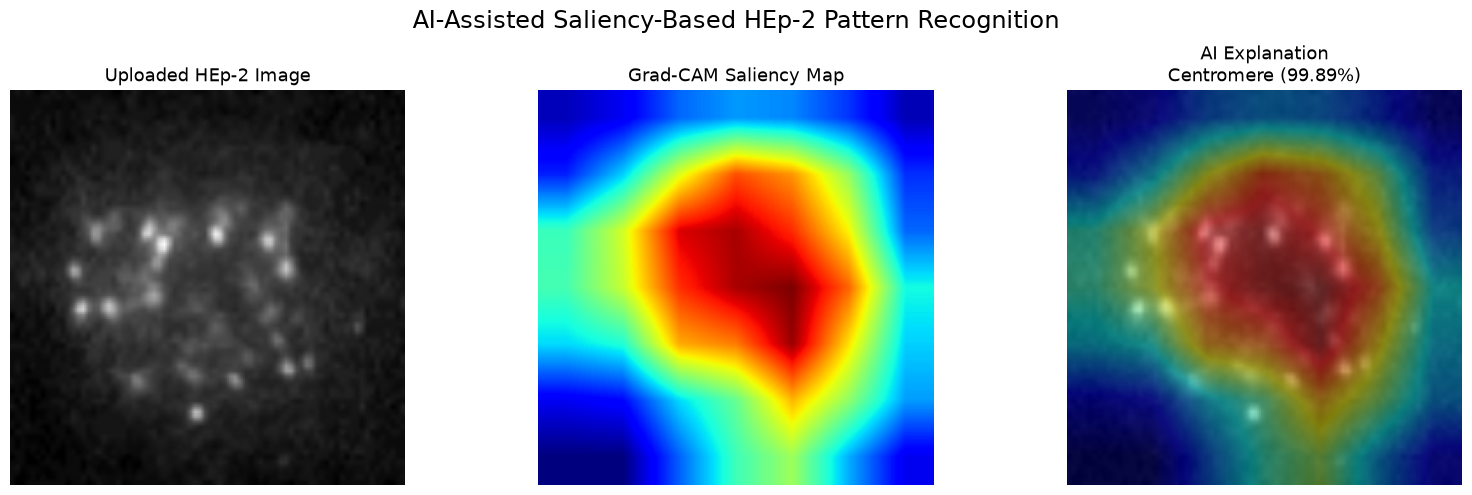

In [9]:
# ==========================================================
# AI-ASSISTED HEp-2 DIAGNOSTIC EXPLANATION
# ==========================================================

import cv2

# ----------------------------------------------------------
# Prepare original image
# ----------------------------------------------------------

original_image = np.array(image)

original_image = cv2.resize(
    original_image,
    (224, 224)
)

# ----------------------------------------------------------
# Resize Grad-CAM
# ----------------------------------------------------------

heatmap = cv2.resize(
    cam,
    (224, 224)
)

# Convert CAM to heatmap
heatmap_uint8 = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------------
# Overlay Grad-CAM on original image
# ----------------------------------------------------------

overlay = cv2.addWeighted(
    original_image,
    0.55,
    heatmap_color,
    0.45,
    0
)

# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

# Original image
axes[0].imshow(original_image)
axes[0].set_title(
    "Uploaded HEp-2 Image",
    fontsize=13
)
axes[0].axis("off")

# Grad-CAM heatmap
axes[1].imshow(
    heatmap,
    cmap="jet"
)
axes[1].set_title(
    "Grad-CAM Saliency Map",
    fontsize=13
)
axes[1].axis("off")

# Overlay
axes[2].imshow(overlay)
axes[2].set_title(
    f"AI Explanation\n"
    f"{class_names[predicted_class]} "
    f"({predicted_confidence:.2f}%)",
    fontsize=13
)
axes[2].axis("off")

plt.suptitle(
    "AI-Assisted Saliency-Based HEp-2 Pattern Recognition",
    fontsize=17
)

plt.tight_layout()
plt.show()

In [10]:
# ==========================================================
# AI-ASSISTED INTERPRETATION REPORT
# ==========================================================

print("\n")
print("=" * 70)
print("AI-ASSISTED HEp-2 INTERPRETATION")
print("=" * 70)

print(f"\nPredicted HEp-2 Pattern : {class_names[predicted_class]}")
print(f"Model                  : DenseNet121")
print(f"Confidence              : {predicted_confidence:.2f}%")

print("\n" + "-" * 70)
print("MODEL-BASED OBSERVATION")
print("-" * 70)

print(
    f"The model predicts the HEp-2 staining morphology as "
    f"{class_names[predicted_class]} with a confidence of "
    f"{predicted_confidence:.2f}%."
)

print(
    "\nThe Grad-CAM visualization highlights the image regions "
    "that contributed most strongly to this classification. "
    "The highlighted regions represent model attention and "
    "should be interpreted together with the original "
    "fluorescence image."
)

print("\n" + "-" * 70)
print("CLASS PROBABILITY PROFILE")
print("-" * 70)

for index in sorted_indices:

    index = index.item()

    print(
        f"{class_names[index]:15s} : "
        f"{probabilities[index].item() * 100:6.2f}%"
    )

print("\n" + "-" * 70)
print("CLINICAL DECISION SUPPORT")
print("-" * 70)

print(
    "This system provides AI-assisted interpretation of "
    "HEp-2 staining morphology. The prediction and saliency "
    "map are intended to support expert assessment and should "
    "be considered alongside the original image and relevant "
    "clinical and laboratory information."
)

print("\n" + "-" * 70)
print("IMPORTANT")
print("-" * 70)

print(
    "AI-assisted research prototype — not a standalone "
    "clinical diagnosis."
)

print("=" * 70)



AI-ASSISTED HEp-2 INTERPRETATION

Predicted HEp-2 Pattern : Centromere
Model                  : DenseNet121
Confidence              : 99.89%

----------------------------------------------------------------------
MODEL-BASED OBSERVATION
----------------------------------------------------------------------
The model predicts the HEp-2 staining morphology as Centromere with a confidence of 99.89%.

The Grad-CAM visualization highlights the image regions that contributed most strongly to this classification. The highlighted regions represent model attention and should be interpreted together with the original fluorescence image.

----------------------------------------------------------------------
CLASS PROBABILITY PROFILE
----------------------------------------------------------------------
Centromere      :  99.89%
Nucleolar       :   0.10%
Speckled        :   0.00%
Homogeneous     :   0.00%
Golgi           :   0.00%
NuMem           :   0.00%

-------------------------------------

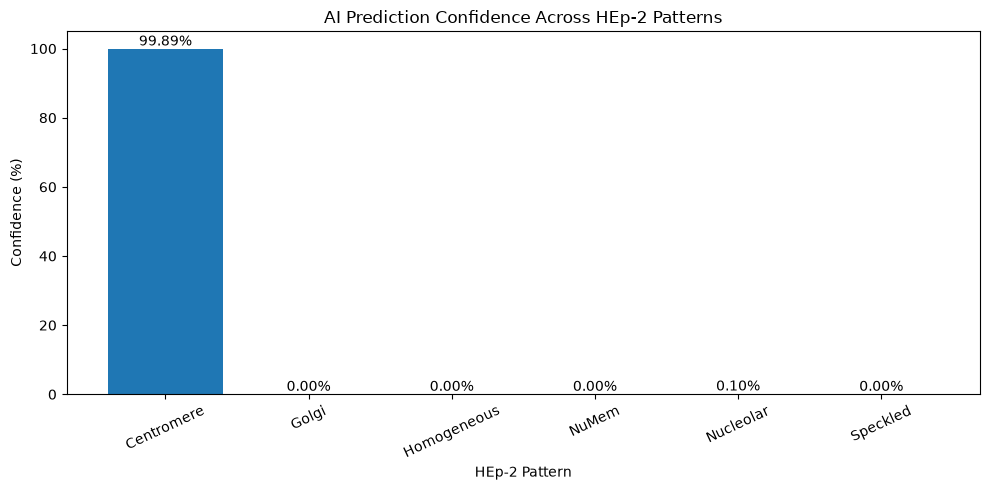

In [11]:
# ==========================================================
# CLASS PROBABILITY PROFILE
# ==========================================================

import matplotlib.pyplot as plt

probability_values = [
    probabilities[i].item() * 100
    for i in range(len(class_names))
]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    class_names,
    probability_values
)

plt.ylabel("Confidence (%)")
plt.xlabel("HEp-2 Pattern")
plt.title("AI Prediction Confidence Across HEp-2 Patterns")

plt.ylim(0, 105)

# Add percentage labels
for bar, value in zip(bars, probability_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()



        AI-ASSISTED HEp-2 PATTERN ANALYSIS SYSTEM

ANALYSIS RESULT
------------------------------------------------------------------------------
  Predicted HEp-2 Pattern : Centromere
  Model Used              : DenseNet121
  Prediction Confidence   : 99.89%

INTERPRETABILITY
------------------------------------------------------------------------------
  Grad-CAM highlights the image regions that contributed
  most strongly to the model's classification decision.

CLINICAL DECISION SUPPORT
------------------------------------------------------------------------------
  This system provides AI-assisted assessment of HEp-2
  staining morphology to support expert interpretation.
  The output should be considered together with the
  original fluorescence image and relevant laboratory
  information.

  RESEARCH PROTOTYPE — NOT A STANDALONE CLINICAL DIAGNOSIS


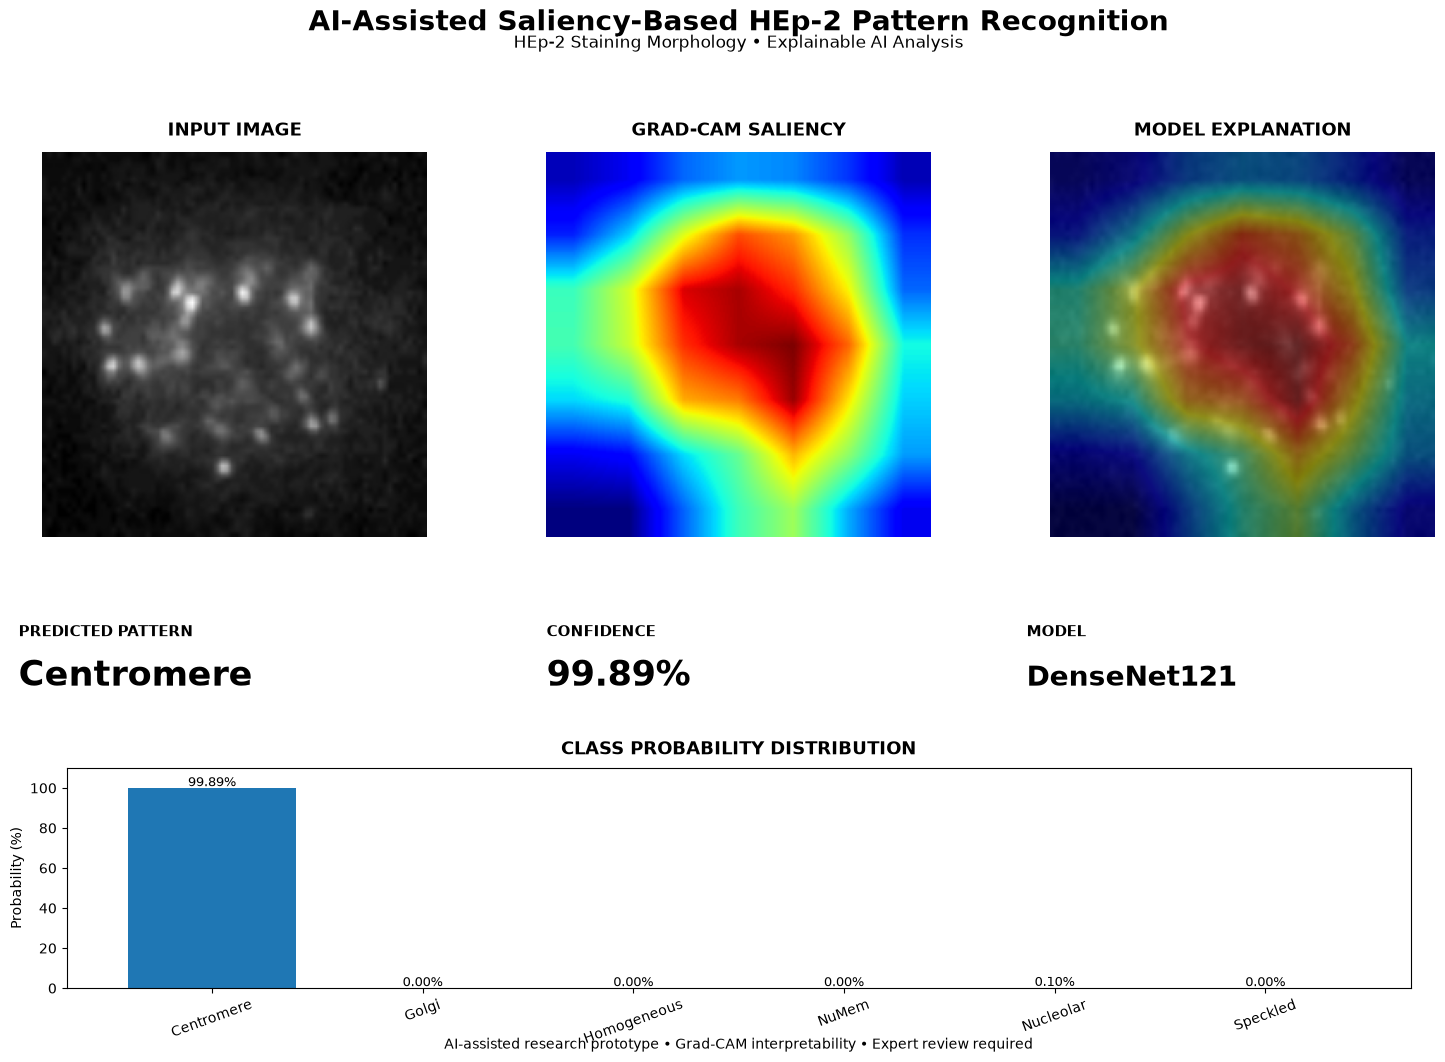

In [12]:
# ==========================================================
# OFFICIAL AI-ASSISTED HEp-2 ANALYSIS REPORT
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Prepare values
# ----------------------------------------------------------

predicted_pattern = class_names[predicted_class]
confidence = predicted_confidence

probability_values = [
    probabilities[i].item() * 100
    for i in range(len(class_names))
]

# ----------------------------------------------------------
# REPORT HEADER
# ----------------------------------------------------------

print("\n")
print("=" * 78)
print("        AI-ASSISTED HEp-2 PATTERN ANALYSIS SYSTEM")
print("=" * 78)

print("\nANALYSIS RESULT")
print("-" * 78)

print(f"  Predicted HEp-2 Pattern : {predicted_pattern}")
print(f"  Model Used              : DenseNet121")
print(f"  Prediction Confidence   : {confidence:.2f}%")

print("\nINTERPRETABILITY")
print("-" * 78)

print(
    "  Grad-CAM highlights the image regions that contributed"
)
print(
    "  most strongly to the model's classification decision."
)

print("\nCLINICAL DECISION SUPPORT")
print("-" * 78)

print(
    "  This system provides AI-assisted assessment of HEp-2"
)
print(
    "  staining morphology to support expert interpretation."
)
print(
    "  The output should be considered together with the"
)
print(
    "  original fluorescence image and relevant laboratory"
)
print(
    "  information."
)

print("\n" + "=" * 78)
print(
    "  RESEARCH PROTOTYPE — NOT A STANDALONE CLINICAL DIAGNOSIS"
)
print("=" * 78)


# ==========================================================
# OFFICIAL VISUAL ANALYSIS PANEL
# ==========================================================

fig = plt.figure(figsize=(16, 11))

# ----------------------------------------------------------
# Top: Title
# ----------------------------------------------------------

fig.suptitle(
    "AI-Assisted Saliency-Based HEp-2 Pattern Recognition",
    fontsize=20,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "HEp-2 Staining Morphology • Explainable AI Analysis",
    ha="center",
    fontsize=12
)

# ----------------------------------------------------------
# Original image
# ----------------------------------------------------------

ax1 = fig.add_axes([0.05, 0.49, 0.27, 0.35])

ax1.imshow(original_image)
ax1.set_title(
    "INPUT IMAGE",
    fontsize=13,
    fontweight="bold",
    pad=12
)
ax1.axis("off")

# ----------------------------------------------------------
# Grad-CAM
# ----------------------------------------------------------

ax2 = fig.add_axes([0.365, 0.49, 0.27, 0.35])

ax2.imshow(
    heatmap,
    cmap="jet"
)

ax2.set_title(
    "GRAD-CAM SALIENCY",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax2.axis("off")

# ----------------------------------------------------------
# Overlay
# ----------------------------------------------------------

ax3 = fig.add_axes([0.68, 0.49, 0.27, 0.35])

ax3.imshow(overlay)

ax3.set_title(
    "MODEL EXPLANATION",
    fontsize=13,
    fontweight="bold",
    pad=12
)

ax3.axis("off")

# ----------------------------------------------------------
# Prediction information box
# ----------------------------------------------------------

fig.text(
    0.05,
    0.40,
    "PREDICTED PATTERN",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.05,
    0.355,
    predicted_pattern,
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.38,
    0.40,
    "CONFIDENCE",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.38,
    0.355,
    f"{confidence:.2f}%",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.68,
    0.40,
    "MODEL",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.68,
    0.355,
    "DenseNet121",
    fontsize=20,
    fontweight="bold"
)

# ----------------------------------------------------------
# Probability distribution
# ----------------------------------------------------------

ax4 = fig.add_axes([0.08, 0.08, 0.84, 0.20])

bars = ax4.bar(
    class_names,
    probability_values
)

ax4.set_title(
    "CLASS PROBABILITY DISTRIBUTION",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax4.set_ylabel(
    "Probability (%)"
)

ax4.set_ylim(
    0,
    max(100, max(probability_values) + 10)
)

ax4.tick_params(
    axis="x",
    rotation=20
)

# Add probability values
for bar, value in zip(bars, probability_values):

    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

# ----------------------------------------------------------
# Footer
# ----------------------------------------------------------

fig.text(
    0.5,
    0.025,
    "AI-assisted research prototype • Grad-CAM interpretability • "
    "Expert review required",
    ha="center",
    fontsize=10
)

plt.show()